In [ ]:
import os
import re
import json
import warnings
import subprocess

import numpy as np
import pandas as pd
from collections import defaultdict
from collections import Counter
from scipy.spatial.distance import pdist, squareform

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

In [ ]:
mpl.rcParams['figure.dpi'] = 300 # change this for high resolution output
warnings.filterwarnings('ignore')
np.seterr(divide='ignore', invalid='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

### Current directory and names of proteins

In [ ]:
base_path = "../example_data/NFIL3_TBL1R/fold_mnfil3x1_mtbl1rx1"
name_protA = "NFIL3" # First modeled protein
name_protB = "TBL1R" # Second modeled protein

### Score PAE, LIS, cLIS and iPTM

In [ ]:
def transform_pae_matrix(pae_matrix, pae_cutoff):
    # Initialize the transformed matrix with zeros
    transformed_pae = np.zeros_like(pae_matrix)

    # Apply transformation: pae = 0 -> score = 1, pae = cutoff -> score = 0, above cutoff -> score = 0
    # Linearly scale values between 0 and cutoff to fall between 1 and 0
    within_cutoff = pae_matrix < pae_cutoff
    transformed_pae[within_cutoff] = 1 - (pae_matrix[within_cutoff] / pae_cutoff)

    return transformed_pae
    

In [ ]:
def calculate_mean_lis(transformed_pae, subunit_number):
    # Calculate the cumulative sum of protein lengths to get the end indices of the submatrices
    cum_lengths = np.cumsum(subunit_number)
    
    # Add a zero at the beginning of the cumulative lengths to get the start indices
    start_indices = np.concatenate(([0], cum_lengths[:-1]))
    
    # Initialize an empty matrix to store the mean LIS
    mean_lis_matrix = np.zeros((len(subunit_number), len(subunit_number)))
    
    # Iterate over the start and end indices
    for i in range(len(subunit_number)):
        for j in range(len(subunit_number)):
            # Get the start and end indices of the interaction submatrix
            start_i, end_i = start_indices[i], cum_lengths[i]
            start_j, end_j = start_indices[j], cum_lengths[j]
            
            # Get the interaction submatrix
            submatrix = transformed_pae[start_i:end_i, start_j:end_j]
            
            # Calculate the mean LIS, considering only non-zero values
            mean_lis = submatrix[submatrix > 0].mean()
            
            # Store the mean LIS in the matrix
            mean_lis_matrix[i, j] = mean_lis

    return mean_lis_matrix
    

In [ ]:
def calculate_contact_map(cif_file, distance_threshold=8):
    def read_cif_lines(cif_path):
        with open(cif_path, 'r') as file:
            lines = file.readlines()

        residue_lines = []
        for line in lines:
            if line.startswith('ATOM') and ('CB' in line or 'GLY' in line and 'CA' in line):
                residue_lines.append(line.strip())  # Store the line if it meets the criteria for ATOM

            if line.startswith('ATOM') and 'P   ' in line:
                residue_lines.append(line.strip()) # Store the line if it meets the criteria for ATOM

            elif line.startswith('HETATM'):
                residue_lines.append(line.strip())  # Store all HETATM lines

        return residue_lines
        
    def lines_to_dataframe(residue_lines):
        # Split lines and create a list of dictionaries for each atom
        data = []
        for line in residue_lines:
            parts = line.split()
            # Correctly convert numerical values
            for i in range(len(parts)):
                try:
                    parts[i] = float(parts[i])
                except ValueError:
                    pass
            data.append(parts)

        df = pd.DataFrame(data)

        # Add line number column
        df.insert(0, 'residue', range(1, 1 + len(df)))

        return df

    # Read lines from CIF file
    residue_lines = read_cif_lines(cif_file)

    # Convert lines to DataFrame
    df = lines_to_dataframe(residue_lines)

    # Assuming the columns for x, y, z coordinates are at indices 11, 12, 13 after insertion
    coordinates = df.iloc[:, 11:14].to_numpy()

    distances = squareform(pdist(coordinates))

    # Assuming the column for atom names is at index 3 after insertion
    has_phosphorus = df.iloc[:, 3].apply(lambda x: 'P' in str(x)).to_numpy()

    # Adjust the threshold for phosphorus-containing residues
    adjusted_distances = np.where(has_phosphorus[:, np.newaxis] | has_phosphorus[np.newaxis, :], 
                                  distances - 4, distances)

    contact_map = np.where(adjusted_distances < distance_threshold, 1, 0)
    #print(contact_map)
        
    return contact_map
    

In [ ]:
def afm3_plot(af3_json, pae_cutoff=12, distance_cutoff=8.0, save="png"):
    model_number = re.search(r'full_data_(\d+)', af3_json).group(1)
    json_data = json.load(open(af3_json,'rb'))
    token_chain_ids = json_data['token_chain_ids']
    chain_residue_counts = Counter(token_chain_ids)
    subunit_number = list(chain_residue_counts.values())    
    pae_matrix = np.array(json_data['pae'])
    pae_matrix = np.nan_to_num(pae_matrix)
    subunit_sizes = subunit_number
    boundaries = np.cumsum(subunit_sizes)[:-1]

    # Extract the base name of the JSON file (without extension)
    json_basename = os.path.splitext(os.path.basename(af3_json))[0]
    pdb_basename = json_basename.replace('_full_data_', '_model_')

    # Construct CIF file path based on JSON file path
    base_path = os.path.dirname(af3_json)
    cif_file = os.path.join(base_path, f'{pdb_basename}.cif')

    # Create a figure with 1 row and 5 columns
    fig, axs = plt.subplots(1, 6, figsize=(30, 6))

    # Plotting the PAE matrix
    cax1 = axs[0].matshow(pae_matrix, cmap='bwr')
    for boundary in boundaries:
        axs[0].axvline(x=boundary, color='black', lw=1, linestyle='-')
        axs[0].axhline(y=boundary, color='black', lw=1, linestyle='-')

    fig.colorbar(cax1, ax=axs[0], label='Predicted Aligned Error (PAE)', shrink=0.5)
    axs[0].set_title(f'Model {model_number} Predicted Aligned Error Map')
    axs[0].xaxis.tick_bottom()

    # Transform the PAE matrix
    transformed_pae_matrix = transform_pae_matrix(pae_matrix, pae_cutoff)
    transformed_pae_matrix = np.nan_to_num(transformed_pae_matrix)

    # Plotting the transformed PAE matrix
    cax2 = axs[1].matshow(transformed_pae_matrix, cmap='Blues', vmin=0, vmax=1)
    for boundary in boundaries:
        axs[1].axvline(x=boundary, color='black', lw=1, linestyle='-')
        axs[1].axhline(y=boundary, color='black', lw=1, linestyle='-')

    fig.colorbar(cax2, ax=axs[1], label='Local Interaction Score (LIS)', shrink=0.5)
    axs[1].set_title(f'Model {model_number} Local Interaction Area Map')
    axs[1].xaxis.tick_bottom()

    # Calculate the mean LIS matrix
    mean_lis_matrix = calculate_mean_lis(transformed_pae_matrix, subunit_sizes)
    mean_lis_matrix = np.nan_to_num(mean_lis_matrix)

    # Plot the mean LIS matrix as a heatmap
    cax3 = axs[2].imshow(mean_lis_matrix, cmap='magma_r', interpolation='nearest', vmin=0, vmax=1)
    fig.colorbar(cax3, ax=axs[2], label='Local Interaction Score (LIS)', shrink=0.5)
    axs[2].set_title(f'Model {model_number} Local Interaction Score Heatmap')
    subunit_labels = [i for i in range(1, len(subunit_sizes)+1)]
    axs[2].set_xticks(np.arange(len(subunit_sizes)))
    axs[2].set_yticks(np.arange(len(subunit_sizes)))
    axs[2].set_xticklabels(subunit_labels)
    axs[2].set_yticklabels(subunit_labels)

    for i in range(len(subunit_sizes)):
        for j in range(len(subunit_sizes)):
            value = mean_lis_matrix[i, j]
            text_color = 'w' if value > 0.5 else 'k'  
            axs[2].text(j, i, format(mean_lis_matrix[i, j], '.3f'), ha='center', va='center', color=text_color)
    
    # Calculate contact map
    contact_map = calculate_contact_map(cif_file, distance_cutoff)
    
    # Create a new map that combines the inverse PAE map with the contact map
    combined_map = np.where((transformed_pae_matrix > 0) & (contact_map == 1), transformed_pae_matrix, 0)

    # Plotting the transformed PAE matrix
    cax4 = axs[3].matshow(combined_map, cmap='Reds', vmin=0, vmax=1)
    for boundary in boundaries:
        axs[3].axvline(x=boundary, color='black', lw=1, linestyle='-')
        axs[3].axhline(y=boundary, color='black', lw=1, linestyle='-')

    fig.colorbar(cax4, ax=axs[3], label='Contact Local Interaction Score (cLIS)', shrink=0.5)
    axs[3].xaxis.tick_bottom()
    axs[3].set_title(f'Model {model_number} Contact Local Interaction Area Map')

    # Calculate the mean LIS matrix
    mean_clis_matrix = calculate_mean_lis(combined_map, subunit_sizes)
    mean_clis_matrix = np.nan_to_num(mean_clis_matrix)

    # Plot the mean cLIS matrix as a heatmap
    cax5 = axs[4].imshow(mean_clis_matrix, cmap='magma_r', interpolation='nearest', vmin=0, vmax=1)
    fig.colorbar(cax5, ax=axs[4], label='Contact Local Interaction Score (cLIS)', shrink=0.5)
    axs[4].set_title(f'Model {model_number} Contact Local Interaction Score Heatmap')
    subunit_labels = [i for i in range(1, len(subunit_sizes)+1)]
    axs[4].set_xticks(np.arange(len(subunit_sizes)))
    axs[4].set_yticks(np.arange(len(subunit_sizes)))
    axs[4].set_xticklabels(subunit_labels)
    axs[4].set_yticklabels(subunit_labels)

    for i in range(len(subunit_sizes)):
        for j in range(len(subunit_sizes)):
            value = mean_clis_matrix[i, j]
            text_color = 'w' if value > 0.5 else 'k'  
            axs[4].text(j, i, format(mean_clis_matrix[i, j], '.3f'), ha='center', va='center', color=text_color)
    
    json_confidence = af3_json.replace('full_data', 'summary_confidences')
    with open(json_confidence, 'r') as file:
        confidence_data = json.load(file)

    iptm_matrix = confidence_data['chain_pair_iptm']

    iptm_matrix = np.array(iptm_matrix, dtype=float)  # Converts None to np.nan automatically
    iptm_matrix = np.nan_to_num(iptm_matrix)
    cax6 = axs[5].imshow(iptm_matrix, cmap='Greens', vmin = 0, vmax = 1, interpolation='nearest')
    fig.colorbar(cax6, ax=axs[5], label='ipTM', shrink=0.5)
    axs[5].set_title(f'Model {model_number} ipTM Heatmap')

    # Set the ticks to start from 1 and be integers
    ticks = np.arange(1, iptm_matrix.shape[0] + 1)
    axs[5].set_xticks(ticks - 1)
    axs[5].set_yticks(ticks - 1)
    axs[5].set_xticklabels(ticks)
    axs[5].set_yticklabels(ticks)

    # Display the values of the IPTM matrix on the heatmap
    for i in range(iptm_matrix.shape[0]):
        for j in range(iptm_matrix.shape[1]):
            value = iptm_matrix[i, j]
            if np.isnan(value):
                continue  # Skip NaN values
            text_color = 'w' if value > 0.7 else 'k'

            axs[5].text(j, i, format(value, '.3f'), ha='center', va='center', color=text_color)

    folder_name = os.path.basename(os.path.dirname(af3_json))
    name = f"{base_path}/Matrices/{folder_name}_afm3_plot_model_{model_number}.{save}"
    os.makedirs(os.path.dirname(name), exist_ok=True)
   
    plt.tight_layout()
    plt.savefig(name, dpi=300)
    plt.show()


In [ ]:
def generate_json_paths(base_path, json, number_of_models=5):
    """
    Generates a list of JSON file paths for a given number of models within a specified base path.

    Parameters:
        - base_path (str): The base directory where the model JSON files are stored.
        - number_of_models (int): The number of model JSON files to generate paths for.
    Returns:
        - list: A list of fully qualified paths to the JSON files.
    """
    
    model_identifier = os.path.basename(base_path)

    if json == "data":
        json_files = [f"{base_path}/{model_identifier}_full_data_{model}.json" for model in range(number_of_models)]
    elif json == "result":
        json_files = [f"{base_path}/{model_identifier}_model_{model}_result.json" for model in range(number_of_models)]
    else:
        print("Wrong format of JSON files: 'data' or 'result'.")
        
    return json_files


In [ ]:
def afm3_plot_average(base_path, af3_jsons, pae_cutoff, distance_cutoff, save="png"):
    
    # Initialize the sum of PAE matrices, transformed PAE matrices, mean LIS matrices, and contact maps
    sum_pae_matrix = None
    sum_transformed_pae_matrix = None
    sum_mean_lis_matrix = None
    sum_contact_lia_map = None
    sum_iptm_matrix = None
    
    for af3_json in af3_jsons:
        json_data = json.load(open(af3_json,'rb'))
        json_confidence = af3_json.replace('full_data', 'summary_confidences')
        confidence_data = json.load(open(json_confidence, 'rb'))
        token_chain_ids = json_data['token_chain_ids']
        chain_residue_counts = Counter(token_chain_ids)
        subunit_number = list(chain_residue_counts.values())    
        pae_matrix = np.array(json_data['pae'])
        subunit_sizes = subunit_number

        cif_file = af3_json.replace('_full_data_', '_model_').replace('.json', '.cif')
        
        # Transform the PAE matrix
        transformed_pae_matrix = transform_pae_matrix(pae_matrix, pae_cutoff)
        transformed_pae_matrix = np.nan_to_num(transformed_pae_matrix)

        # Calculate the mean LIS matrix
        mean_lis_matrix = calculate_mean_lis(transformed_pae_matrix, subunit_sizes)
        mean_lis_matrix = np.nan_to_num(mean_lis_matrix)

        contact_map = calculate_contact_map(cif_file, distance_cutoff)
        combined_map = np.where((transformed_pae_matrix > 0) & (contact_map == 1), transformed_pae_matrix, 0)
        
        iptm_matrix = confidence_data['chain_pair_iptm']
        iptm_matrix = np.array(iptm_matrix, dtype=float)  # Converts None to np.nan automatically
        iptm_matrix = np.nan_to_num(iptm_matrix)

        # Add the matrices to the sum
        if sum_pae_matrix is None:
            sum_pae_matrix = pae_matrix
            sum_transformed_pae_matrix = transformed_pae_matrix
            sum_mean_lis_matrix = mean_lis_matrix
            sum_contact_lia_map = combined_map
            sum_iptm_matrix = iptm_matrix
        else:
            sum_pae_matrix += pae_matrix
            sum_transformed_pae_matrix += transformed_pae_matrix
            sum_mean_lis_matrix += mean_lis_matrix
            sum_contact_lia_map += combined_map
            sum_iptm_matrix += iptm_matrix
    
    # Calculate the average matrices
    avg_pae_matrix = sum_pae_matrix / len(af3_jsons)
    avg_transformed_pae_matrix = sum_transformed_pae_matrix / len(af3_jsons)
    avg_mean_lis_matrix = sum_mean_lis_matrix / len(af3_jsons)
    sum_contact_lia_map = sum_contact_lia_map / len(af3_jsons)
    avg_iptm_matrix = sum_iptm_matrix / len(af3_jsons)
    
    # Replace nan with 0 
    avg_pae_matrix = np.nan_to_num(avg_pae_matrix)
    avg_transformed_pae_matrix = np.nan_to_num(avg_transformed_pae_matrix)
    avg_mean_lis_matrix = np.nan_to_num(avg_mean_lis_matrix)
    avg_iptm_matrix = np.nan_to_num(avg_iptm_matrix)

    # Create a figure with 1 row and 5 columns
    fig, axs = plt.subplots(1, 6, figsize=(30, 5))

    # Calculate the cumulative sum of subunit sizes to get the boundaries
    boundaries = np.cumsum(subunit_sizes)[:-1]

    # Plotting the average PAE matrix
    cax1 = axs[0].matshow(avg_pae_matrix, cmap='bwr')
    fig.colorbar(cax1, ax=axs[0], label='Average Predicted Aligned Error (PAE)', shrink=0.5)
    axs[0].set_title('Average Predicted Aligned Error Map')
    axs[0].xaxis.tick_bottom()

    # Add vertical and horizontal lines at the boundaries
    for boundary in boundaries:
        axs[0].axvline(x=boundary, color='black', lw=1, linestyle='-')
        axs[0].axhline(y=boundary, color='black', lw=1, linestyle='-')

    # Plotting the average transformed PAE matrix
    cax2 = axs[1].matshow(avg_transformed_pae_matrix, cmap='Blues', vmin=0, vmax=1)
    fig.colorbar(cax2, ax=axs[1], label='Average Local Interaction Score (LIS)', shrink=0.5)
    axs[1].set_title('Average Local Interaction Area Map')
    axs[1].xaxis.tick_bottom()

    # Add vertical and horizontal lines at the boundaries
    for boundary in boundaries:
        axs[1].axvline(x=boundary, color='black', lw=1, linestyle='-')
        axs[1].axhline(y=boundary, color='black', lw=1, linestyle='-')

    # Plot the average mean LIS matrix as a heatmap
    cax3 = axs[2].imshow(avg_mean_lis_matrix, cmap='magma_r', interpolation='nearest', vmin=0, vmax=1)
    fig.colorbar(cax3, ax=axs[2], label='Average Local Interaction Score (LIS)', shrink=0.5)
    axs[2].set_title('Average Local Interaction Score Heatmap')
    subunit_labels = [i for i in range(1, len(subunit_sizes)+1)]
    axs[2].set_xticks(np.arange(len(subunit_sizes)))
    axs[2].set_yticks(np.arange(len(subunit_sizes)))
    axs[2].set_xticklabels(subunit_labels)
    axs[2].set_yticklabels(subunit_labels)

    for i in range(len(subunit_sizes)):
        for j in range(len(subunit_sizes)):
            value = avg_mean_lis_matrix[i, j]
            text_color = 'w' if value > 0.5 else 'k'  
            axs[2].text(j, i, format(value, '.3f'), ha='center', va='center', color=text_color)

    # Plotting the average mean contact LIS PAE matrix
    cax4 = axs[3].matshow(sum_contact_lia_map, cmap='Reds', vmin=0, vmax=1)
    for boundary in boundaries:
        axs[3].axvline(x=boundary, color='black', lw=1, linestyle='-')
        axs[3].axhline(y=boundary, color='black', lw=1, linestyle='-')

    fig.colorbar(cax4, ax=axs[3], label='Average Contact Local Interaction Score (cLIS)', shrink=0.5)
    axs[3].xaxis.tick_bottom()
    axs[3].set_title(f'Average Contact Local Interaction Area Map')

    # Calculate the mean LIS matrix
    mean_clis_matrix = calculate_mean_lis(sum_contact_lia_map, subunit_sizes)
    mean_clis_matrix = np.nan_to_num(mean_clis_matrix)

    # Plot the mean cLIS matrix as a heatmap
    cax5 = axs[4].imshow(mean_clis_matrix, cmap='magma_r', interpolation='nearest', vmin=0, vmax=1)
    fig.colorbar(cax5, ax=axs[4], label='Average Contact Local Interaction Score (cLIS)', shrink=0.5)
    axs[4].set_title(f'Average Contact Local Interaction Score Heatmap')
    subunit_labels = [i for i in range(1, len(subunit_sizes)+1)]
    axs[4].set_xticks(np.arange(len(subunit_sizes)))
    axs[4].set_yticks(np.arange(len(subunit_sizes)))
    axs[4].set_xticklabels(subunit_labels)
    axs[4].set_yticklabels(subunit_labels)

    for i in range(len(subunit_sizes)):
        for j in range(len(subunit_sizes)):
            value = mean_clis_matrix[i, j]
            text_color = 'w' if value > 0.5 else 'k'  
            axs[4].text(j, i, format(mean_clis_matrix[i, j], '.3f'), ha='center', va='center', color=text_color)

    cax6 = axs[5].imshow(avg_iptm_matrix, cmap='Greens', vmin = 0, vmax = 1, interpolation='nearest')
    fig.colorbar(cax6, ax=axs[5], label='ipTM', shrink=0.5)
    axs[5].set_title(f'Average ipTM Heatmap')

    # Set the ticks to start from 1 and be integers
    ticks = np.arange(1, avg_iptm_matrix.shape[0] + 1)
    axs[5].set_xticks(ticks - 1)
    axs[5].set_yticks(ticks - 1)
    axs[5].set_xticklabels(ticks)
    axs[5].set_yticklabels(ticks)

    # Display the values of the IPTM matrix on the heatmap
    for i in range(avg_iptm_matrix.shape[0]):
        for j in range(avg_iptm_matrix.shape[1]):
            value = avg_iptm_matrix[i, j]
            if np.isnan(value):
                continue  # Skip NaN values
            text_color = 'w' if value > 0.7 else 'k'
            axs[5].text(j, i, format(value, '.3f'), ha='center', va='center', color=text_color)

    folder_name = os.path.basename(os.path.dirname(af3_json))
    name = f"{base_path}/Matrices/{folder_name}_afm3_plot_average.{save}"
    os.makedirs(os.path.dirname(name), exist_ok=True)

    plt.tight_layout()
    plt.savefig(name, dpi=300)
    plt.show()

    # Save residues matrix
    df_contact_lis = pd.DataFrame(sum_contact_lia_map)
    df_lis_matrix = pd.DataFrame(avg_transformed_pae_matrix)

    model_identifier = os.path.basename(base_path)
    with open(f"{base_path}/{model_identifier}_job_request.json", "r") as f:
        data = json.load(f)
    
    seq1 = data[0]["sequences"][0]["proteinChain"]["sequence"]
    len_seq1 = len(seq1)
    seq2 = data[0]["sequences"][1]["proteinChain"]["sequence"]
    len_seq2 = len(seq2)
    
    df_clis_AvsB = df_contact_lis.iloc[0:len_seq1,len_seq1:(len_seq1+len_seq2)]
    df_clis_AvsB.to_csv(f"{base_path}/Matrices/matrix_clis_AvsB.csv")
    df_clis_BvsA = df_contact_lis.iloc[len_seq1:(len_seq1+len_seq2),0:len_seq1]
    df_clis_BvsA.to_csv(f"{base_path}/Matrices/matrix_clis_BvsA.csv")

    df_lis_AvsB = df_lis_matrix.iloc[0:len_seq1,len_seq1:(len_seq1+len_seq2)]
    df_lis_AvsB.to_csv(f"{base_path}/Matrices/matrix_lis_AvsB.csv")
    df_lis_BvsA = df_lis_matrix.iloc[len_seq1:(len_seq1+len_seq2),0:len_seq1]
    df_lis_BvsA.to_csv(f"{base_path}/Matrices/matrix_lis_BvsA.csv")
    

In [ ]:
def afm3_plot_average_to_df(af3_jsons, pae_cutoff=12, distance_cutoff=8, result_save=True):
    sum_pae_matrix = None
    sum_transformed_pae_matrix = None
    sum_mean_lis_matrix = None
    sum_contact_lia_map = None
    sum_iptm_matrix = None
    all_interactions = []

    for af3_json in af3_jsons:
        json_data = json.load(open(af3_json, 'rb'))
        json_confidence = af3_json.replace('full_data', 'summary_confidences')
        confidence_data = json.load(open(json_confidence, 'rb'))
        token_chain_ids = json_data['token_chain_ids']
        chain_residue_counts = Counter(token_chain_ids)
        subunit_number = list(chain_residue_counts.values())
        pae_matrix = np.array(json_data['pae'])
        subunit_sizes = subunit_number

        cif_file = af3_json.replace('_full_data_', '_model_').replace('.json', '.cif')
        
        transformed_pae_matrix = transform_pae_matrix(pae_matrix, pae_cutoff)
        transformed_pae_matrix = np.nan_to_num(transformed_pae_matrix)
        lia_map = np.where(transformed_pae_matrix > 0, 1, 0)

        mean_lis_matrix = calculate_mean_lis(transformed_pae_matrix, subunit_sizes)
        mean_lis_matrix = np.nan_to_num(mean_lis_matrix)

        contact_map = calculate_contact_map(cif_file, distance_cutoff)
        combined_map = np.where((transformed_pae_matrix > 0) & (contact_map == 1), transformed_pae_matrix, 0)
        
        mean_clis_matrix = calculate_mean_lis(combined_map, subunit_sizes)
        mean_clis_matrix = np.nan_to_num(mean_clis_matrix)

        lia_matrix = np.zeros((len(subunit_sizes), len(subunit_sizes)))
        lir_matrix = np.zeros((len(subunit_sizes), len(subunit_sizes)))
        clia_matrix = np.zeros((len(subunit_sizes), len(subunit_sizes)))
        clir_matrix = np.zeros((len(subunit_sizes), len(subunit_sizes)))

        for i in range(len(subunit_sizes)):
            for j in range(len(subunit_sizes)):
                start_i, end_i = sum(subunit_sizes[:i]), sum(subunit_sizes[:i+1])
                start_j, end_j = sum(subunit_sizes[:j]), sum(subunit_sizes[:j+1])
                interaction_submatrix = lia_map[start_i:end_i, start_j:end_j]

                lia_matrix[i, j] = int(np.count_nonzero(interaction_submatrix))
                residues_i = np.unique(np.where(interaction_submatrix > 0)[0]) + start_i
                residues_j = np.unique(np.where(interaction_submatrix > 0)[1]) + start_j
                lir_matrix[i, j] = int(len(residues_i) + len(residues_j))

                combined_submatrix = combined_map[start_i:end_i, start_j:end_j]
                clia_matrix[i, j] = int(np.count_nonzero(combined_submatrix))

                residues_i = np.unique(np.where(combined_submatrix > 0)[0]) + start_i
                residues_j = np.unique(np.where(combined_submatrix > 0)[1]) + start_j
                clir_matrix[i, j] = int(len(residues_i) + len(residues_j))

        iptm_matrix = confidence_data['chain_pair_iptm']
        iptm_matrix = np.array(iptm_matrix, dtype=float)
        iptm_matrix = np.nan_to_num(iptm_matrix)

        if sum_pae_matrix is None:
            sum_pae_matrix = pae_matrix
            sum_transformed_pae_matrix = transformed_pae_matrix
            sum_mean_lis_matrix = mean_lis_matrix
            sum_contact_lia_map = combined_map
            sum_iptm_matrix = iptm_matrix
        else:
            sum_pae_matrix += pae_matrix
            sum_transformed_pae_matrix += transformed_pae_matrix
            sum_mean_lis_matrix += mean_lis_matrix
            sum_contact_lia_map += combined_map
            sum_iptm_matrix += iptm_matrix

        model_number = re.search(r'full_data_(\d+)', af3_json).group(1)
        folder_name = os.path.basename(os.path.dirname(af3_json))
        for i in range(len(subunit_sizes)):
            for j in range(len(subunit_sizes)):
                interaction = {
                    'folder_name': folder_name,
                    'model_number': model_number,
                    'protein_1': i + 1,
                    'protein_2': j + 1,
                    'LIS': mean_lis_matrix[i, j],
                    'LIA': lia_matrix[i, j],
                    'LIR': lir_matrix[i, j],
                    'cLIS': mean_clis_matrix[i, j],
                    'cLIA': clia_matrix[i, j],
                    'cLIR': clir_matrix[i, j],
                    'iptm': iptm_matrix[i, j],
                }
                all_interactions.append(interaction)

    avg_pae_matrix = sum_pae_matrix / len(af3_jsons)
    avg_transformed_pae_matrix = sum_transformed_pae_matrix / len(af3_jsons)
    avg_mean_lis_matrix = sum_mean_lis_matrix / len(af3_jsons)
    avg_contact_lia_map = sum_contact_lia_map / len(af3_jsons)
    avg_iptm_matrix = sum_iptm_matrix / len(af3_jsons)

    avg_pae_matrix = np.nan_to_num(avg_pae_matrix)
    avg_transformed_pae_matrix = np.nan_to_num(avg_transformed_pae_matrix)
    avg_mean_lis_matrix = np.nan_to_num(avg_mean_lis_matrix)
    avg_iptm_matrix = np.nan_to_num(avg_iptm_matrix)

    df_interactions = pd.DataFrame(all_interactions)
    df_interactions['interaction'] = df_interactions.apply(lambda row: tuple(sorted((row['protein_1'], row['protein_2']))), axis=1)
    df_merged = df_interactions.groupby(['folder_name', 'model_number', 'interaction']).mean().reset_index()
    df_merged[['protein_1', 'protein_2']] = pd.DataFrame(df_merged['interaction'].tolist(), index=df_merged.index)
    df_merged = df_merged.drop(columns=['interaction'])

    # Calculate average values for each protein pair and add as new rows
    avg_rows = []
    interaction_pairs = df_merged.groupby(['protein_1', 'protein_2'])

    for (protein_1, protein_2), group in interaction_pairs:
        avg_row = {
            'folder_name': folder_name,
            'model_number': 'average',
            'protein_1': protein_1,
            'protein_2': protein_2,
            'LIS': group['LIS'].mean(),
            'LIA': group['LIA'].mean(),
            'LIR': group['LIR'].mean(),
            'cLIS': group['cLIS'].mean(),
            'cLIA': group['cLIA'].mean(),
            'cLIR': group['cLIR'].mean(),
            'iptm': group['iptm'].mean(),
        }
        avg_rows.append(avg_row)

    df_avg = pd.DataFrame(avg_rows)
    df_merged = pd.concat([df_merged, df_avg], ignore_index=True)

    df_merged['LIA'] = df_merged['LIA'].astype(int)
    df_merged['LIR'] = df_merged['LIR'].astype(int)
    df_merged['cLIA'] = df_merged['cLIA'].astype(int)
    df_merged['cLIR'] = df_merged['cLIR'].astype(int)

    # Save DataFrame to CSV
    output_folder = os.path.dirname(af3_jsons[0])
    output_path = os.path.join(output_folder, f"Matrices/{folder_name}_lis_analysis.csv")
    if result_save == True:
        df_merged.to_csv(output_path, index=False)
        print("Results saved to: ", output_path)

    return df_merged
    

### Plot AF3 score

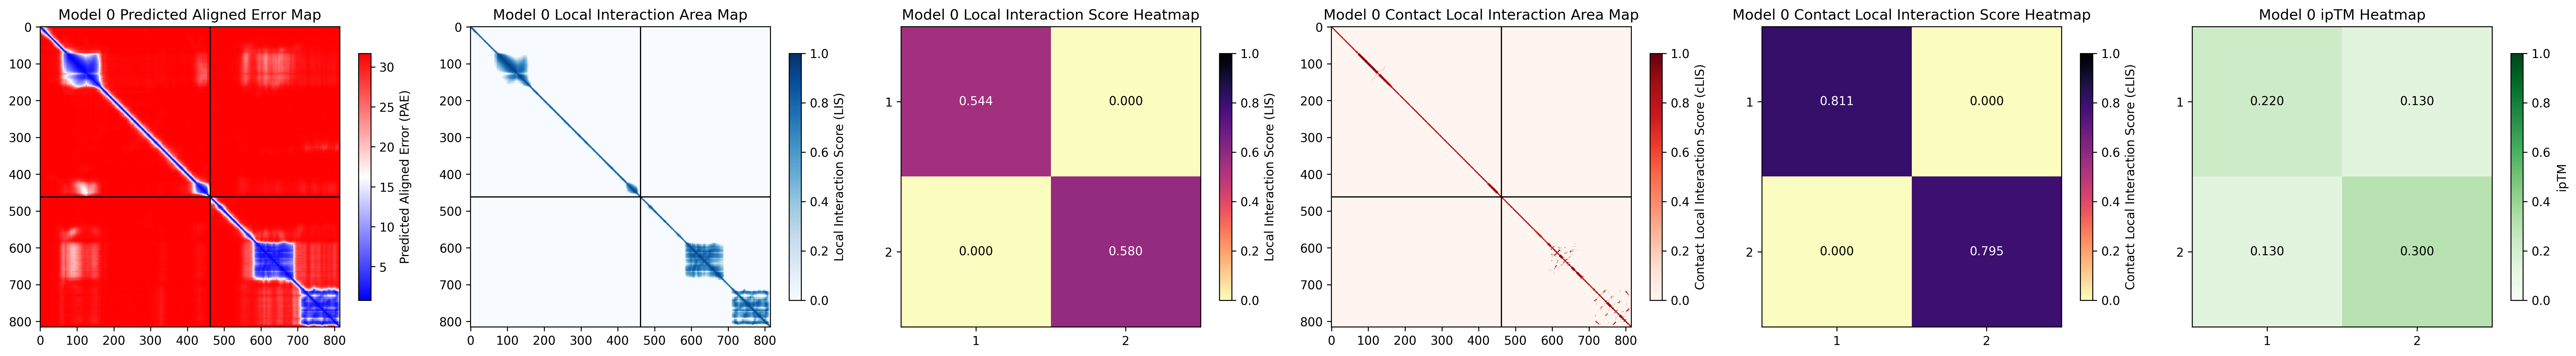

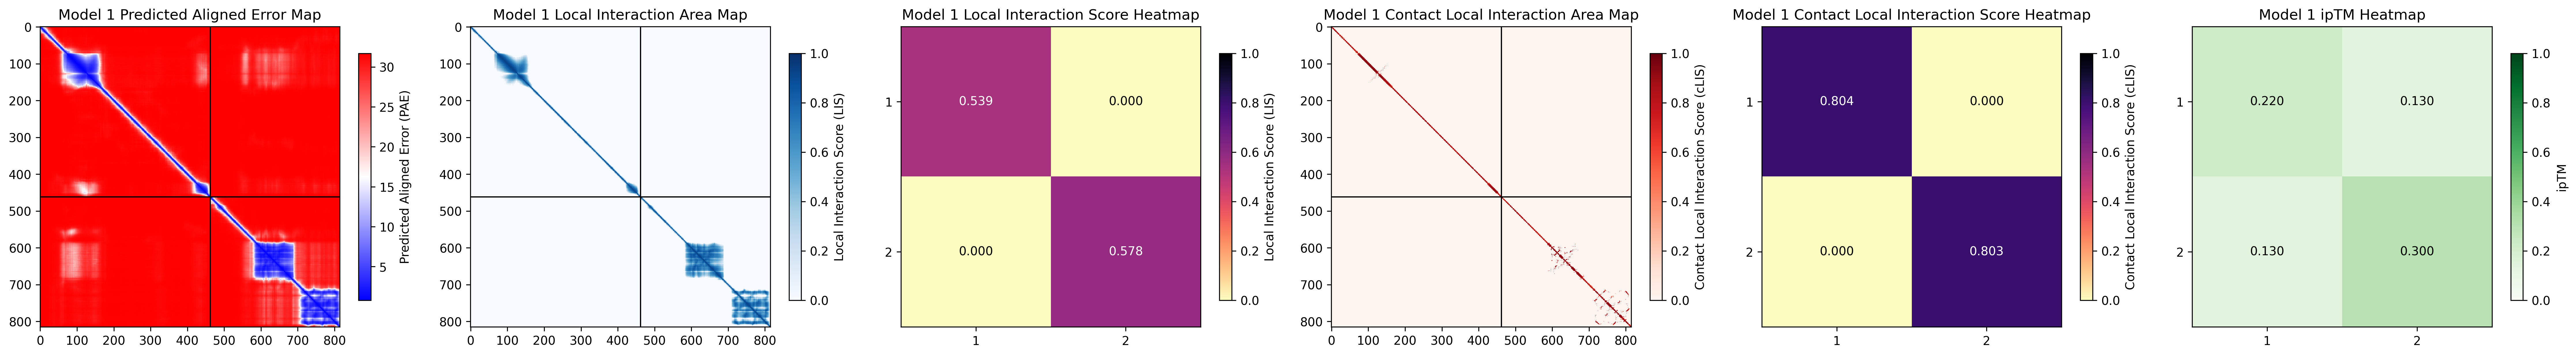

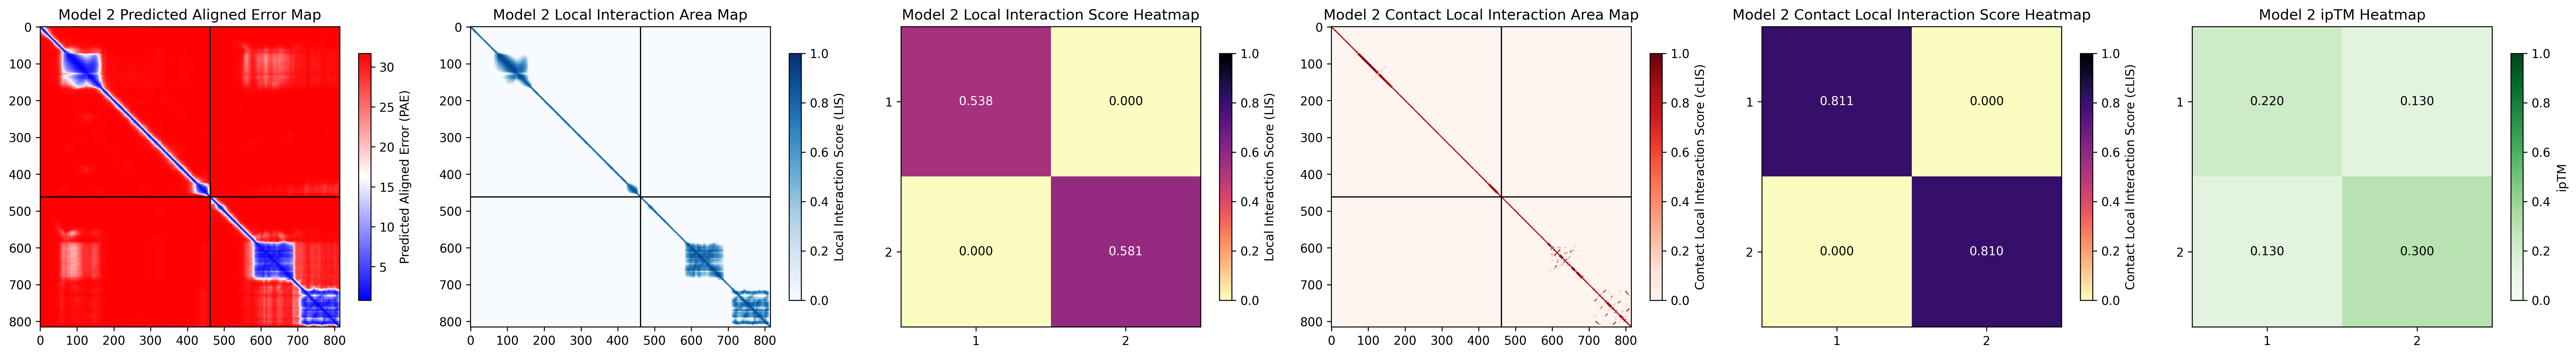

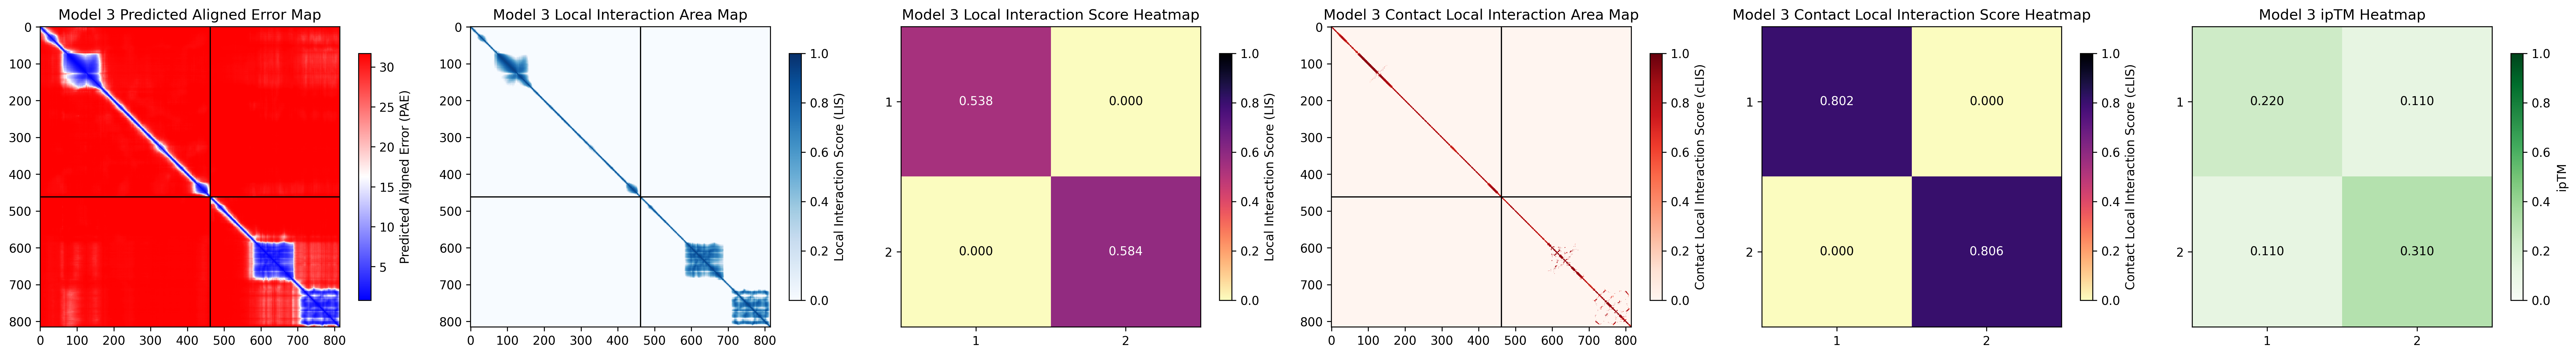

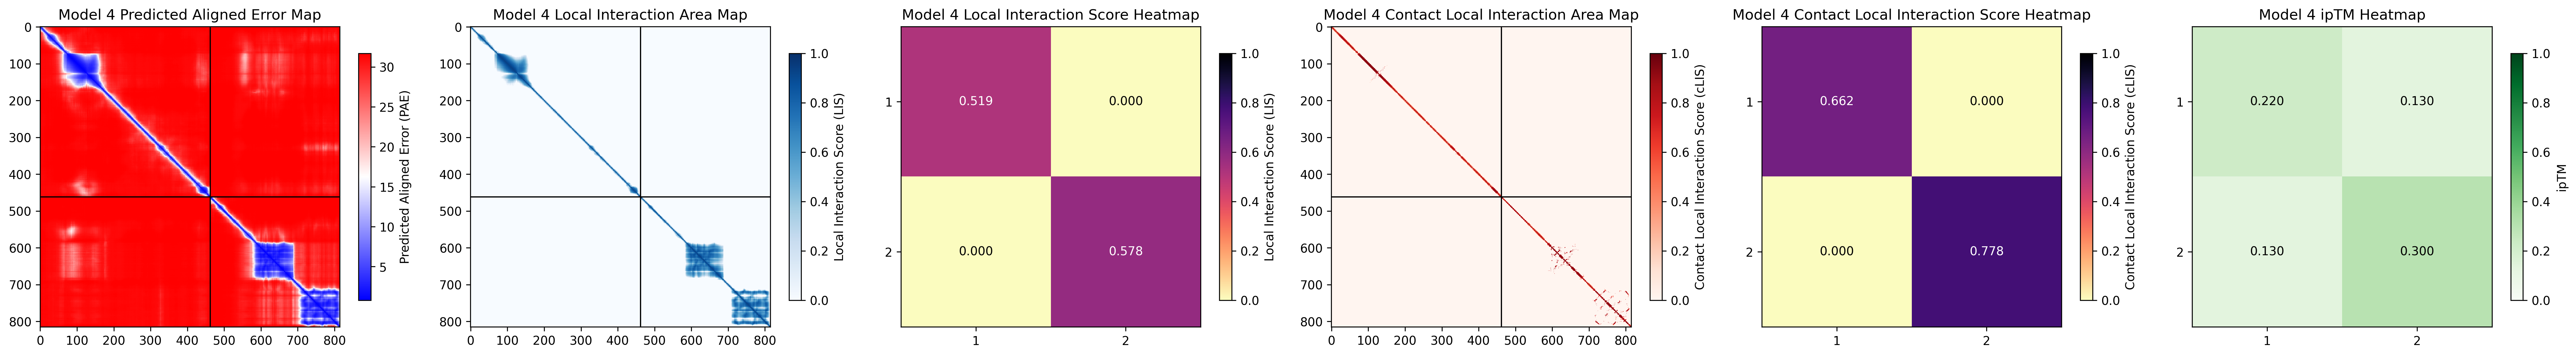

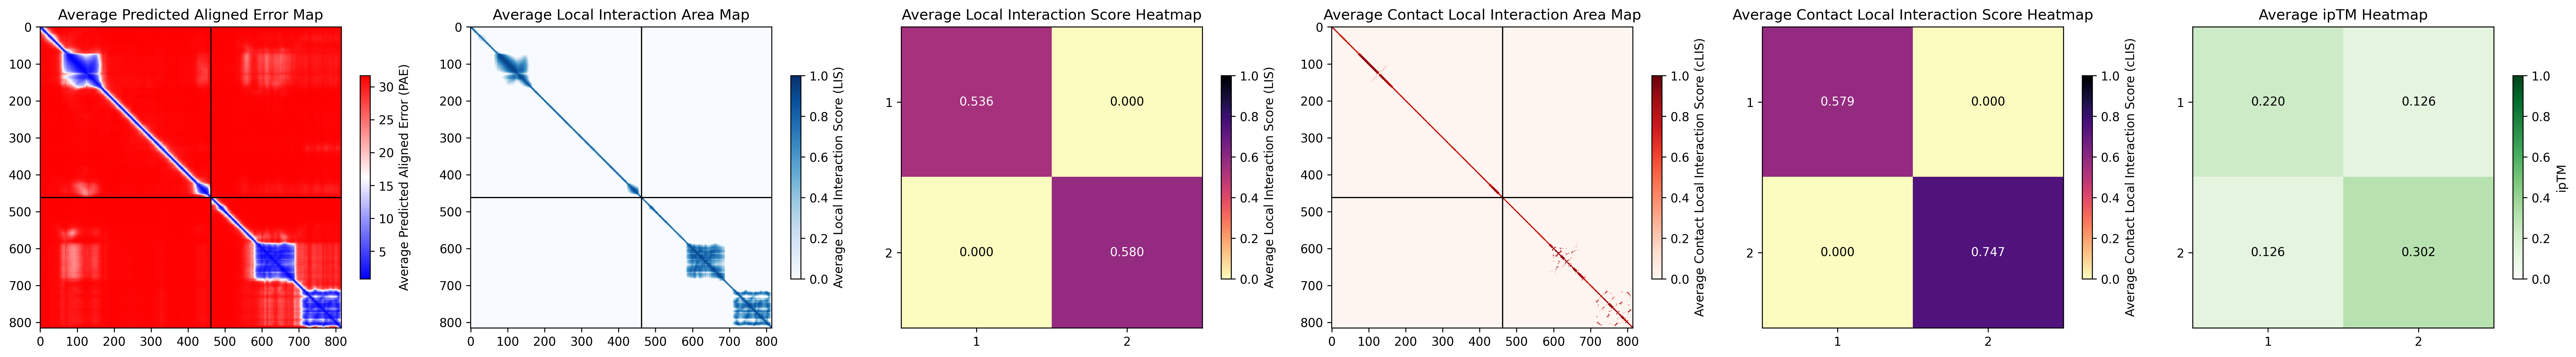

Results saved to:  C:/Users/e216138h/Downloads/fold_mnfil3_mpcgf6\Matrices/fold_mnfil3_mpcgf6_lis_analysis.csv


In [ ]:
json_files = generate_json_paths(base_path, "data")
pae_cutoff = 12
distance_cutoff = 8
result_save = True

for json_file in json_files:
    afm3_plot(json_file, pae_cutoff, distance_cutoff)

afm3_plot_average(base_path, json_files, pae_cutoff, distance_cutoff)
df_interactions = afm3_plot_average_to_df(json_files, pae_cutoff, distance_cutoff)

### pLDDT analisys

In [ ]:
def merge_plddt_by_chain(directory, output_file="merged_results.json"):
    """
    Merge multiple JSON files and average Ca plDDT per residue per chain.

    Parameters:
        - directory (str): Paths to input JSON files
    Returns:
        - output_file (str): Path to output merged JSON
        - merged (dict): dictionary with data merged
    """

    # Run "select_plddt_CA.sh" must be in the same directory
    bash_directory = directory.replace("C:/", "/mnt/c/")
    subprocess.run(["bash", "../selec_plDDT_CA.sh", f"{bash_directory}"], capture_output=True, text=True)

    json_files = generate_json_paths(base_path, "result")

    # Structure : chain -> residue_index -> list of pLDDT values
    data = defaultdict(lambda: defaultdict(list))

    for file in json_files:
        with open(file, 'r') as f:
            j = json.load(f)

        nbr_res = j["nbr_res"]
        plddt = j["plDDT"]
        chains = j["chain"]

        for res, score, ch in zip(nbr_res, plddt, chains):
            data[ch][res].append(score)

    # Compute averages
    merged = {}
    for ch in data:
        residues = sorted(data[ch].keys())
        avg_plddt = [float(np.mean(data[ch][res])) for res in residues]
        merged[ch] = {"residues": residues, "plDDT_mean": avg_plddt}

    # Save JSON
    output_path = os.path.join(directory, output_file)
    with open(output_path, "w") as f:
        json.dump(merged, f, indent=2)

    return merged


In [ ]:
def plot_plddt_averaged(merge_plddt, protA, protB, save="png"):
    """
    Plot the plDDT score for each chain.
    
    Parameters:
        - merge_plddt (dict): dictionary with plDDT data merged and average
        - protA/B (str): Name of each proteins
        - save (str): File plot format (PDF or PNG)
    """

    all_res = []
    for chain, data in merge_plddt.items():
        all_res.extend(data["residues"])
        xmin, xmax = min(all_res), max(all_res)
        
        plt.figure(figsize=(30, 10), dpi=300)
        plt.plot(data["residues"], data["plDDT_mean"], linewidth=2)
        
        if chain == "A":
            plt.title(f"Mean pLDDT for {protA}", fontsize=16)
        else:
            plt.title(f"Mean pLDDT for {protB}", fontsize=16)
        plt.xlabel("Residue", fontsize=12)
        plt.xticks(np.arange(xmin, xmax + 1, 50))
        plt.ylabel("Mean pLDDT", fontsize=12)
        plt.yticks(np.linspace(0, 100, 5))
        
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.grid(color="0.9", linestyle="-", linewidth=0.5)

        save_path = f"{base_path}/plDDT/"
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        
        if chain == "A":
            plt.savefig(f"{save_path}mean_plddt_{protA}.{save}", dpi=300)
        else:
            plt.savefig(f"{save_path}mean_plddt_{protB}.{save}", dpi=300)
        
        plt.show()


In [ ]:
def plot_plddt(path, protA, protB, save="png"):
    """
    Plot the plDDT score for each chain separately.
    
    Parameters:
        - path (str): Path to the plDDT JSON file
        - protA/B (str): Name of each proteins
        - save (str): File plot format (PDF or PNG)
    """
    
    for chain in ["A", "B"]:
        with open(path, "r") as f:
            plddt_data = json.load(f)
        
        residues = plddt_data["nbr_res"]
        plddt = plddt_data["plDDT"]
        
        plt.figure(figsize=(30, 10), dpi=300)
        plt.plot(residues, plddt, linewidth=2)
        
        if chain == "A":
            plt.title(f"pLDDT for {protA}", fontsize=16)
        else:
            plt.title(f"pLDDT for {protB}", fontsize=16)
        
        plt.xlabel("Residue", fontsize=12)
        plt.xticks(np.arange(min(residues), max(residues) + 1, 50))
        plt.ylabel("pLDDT", fontsize=12)
        plt.yticks(np.linspace(0, 100, 5))
        
        plt.gca().spines["top"].set_visible(False)
        plt.gca().spines["right"].set_visible(False)
        plt.grid(color="0.9", linestyle="-", linewidth=0.5)

        save_path = f"{base_path}/plDDT/"
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        
        if chain == "A":
            plt.savefig(f"{save_path}plddt_{protA}.{save}", dpi=300)
        else:
            plt.savefig(f"{save_path}plddt_{protB}.{save}", dpi=300)
        
        plt.show()

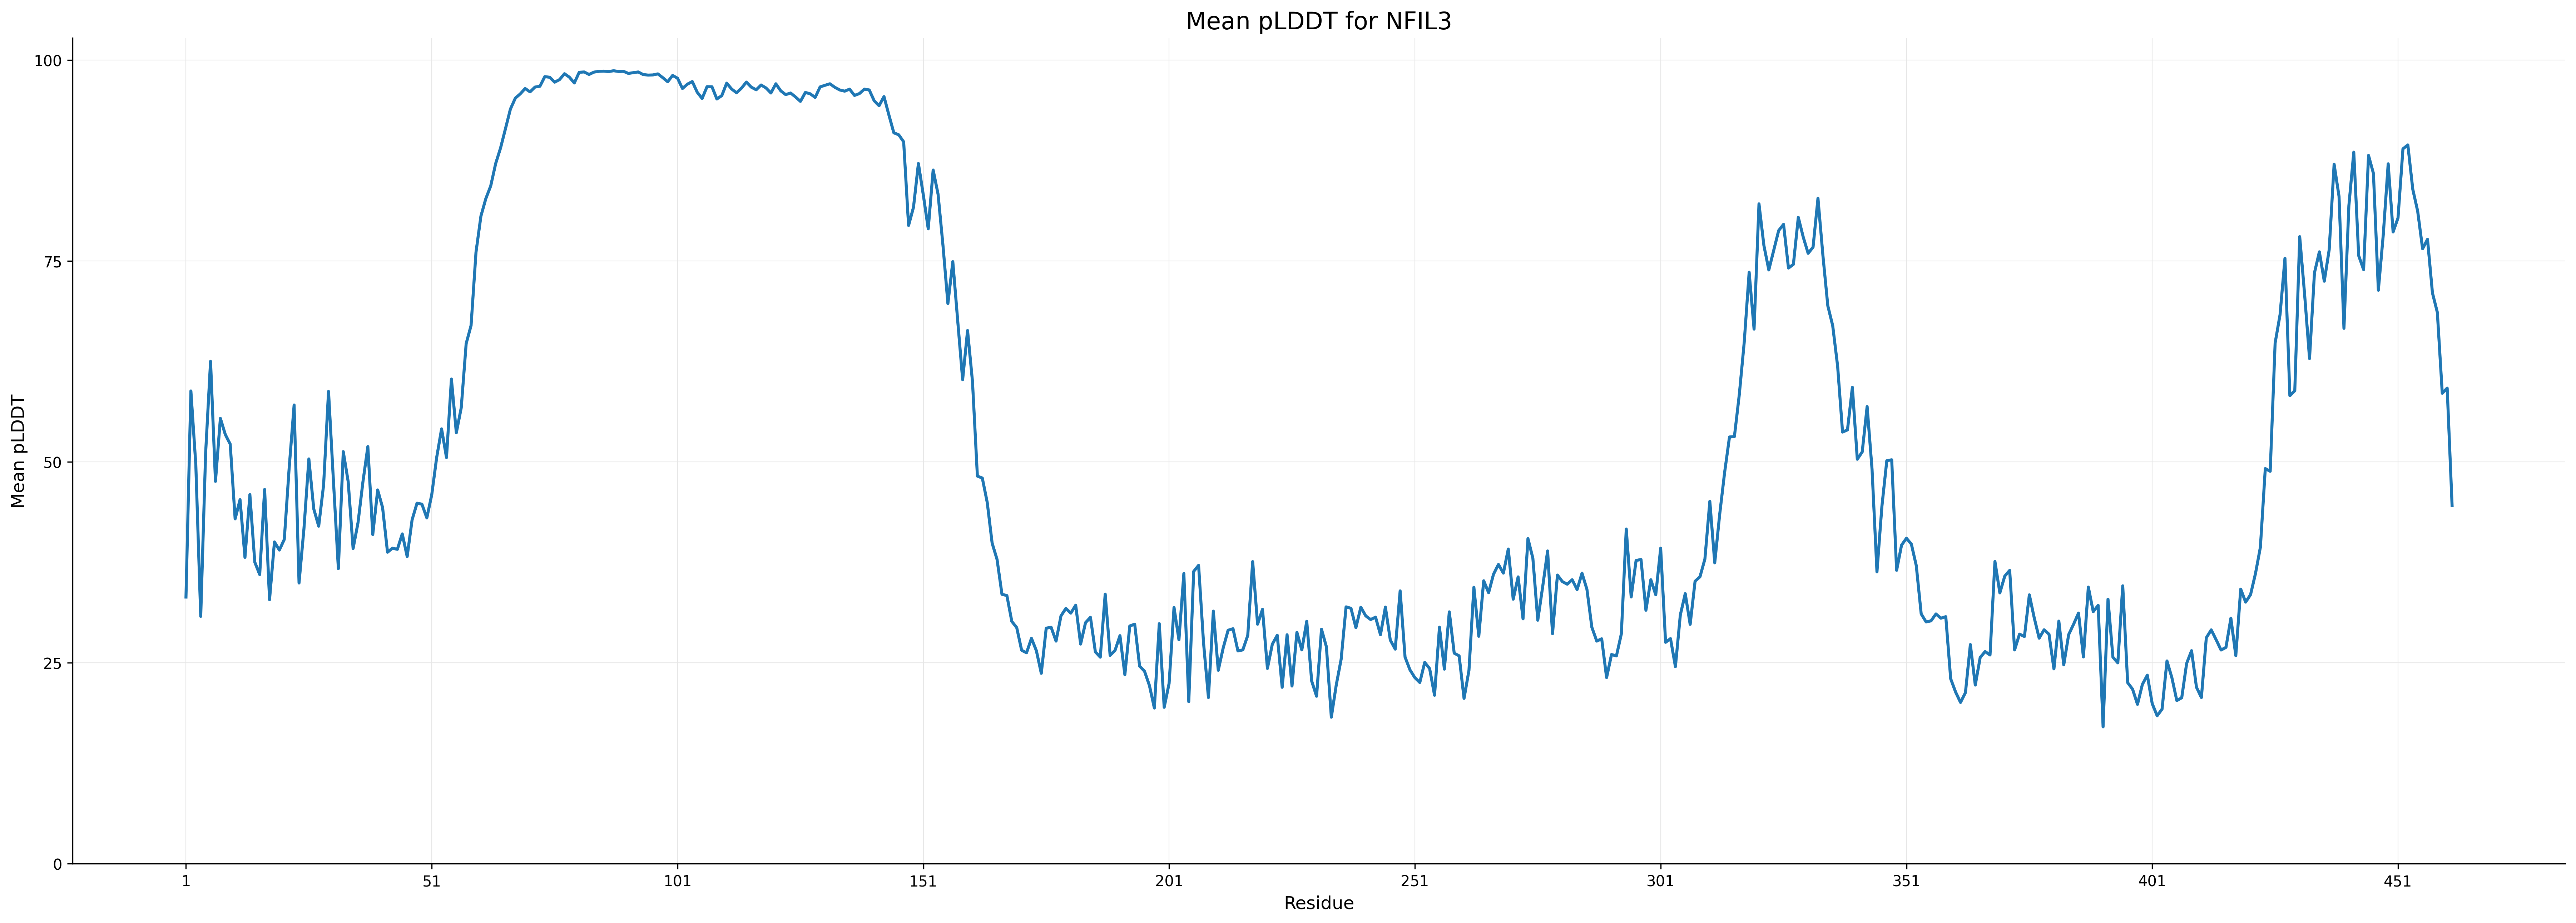

In [ ]:
merge_plddt = merge_plddt_by_chain(base_path)
plot_plddt_averaged(merge_plddt, name_protA, name_protB)

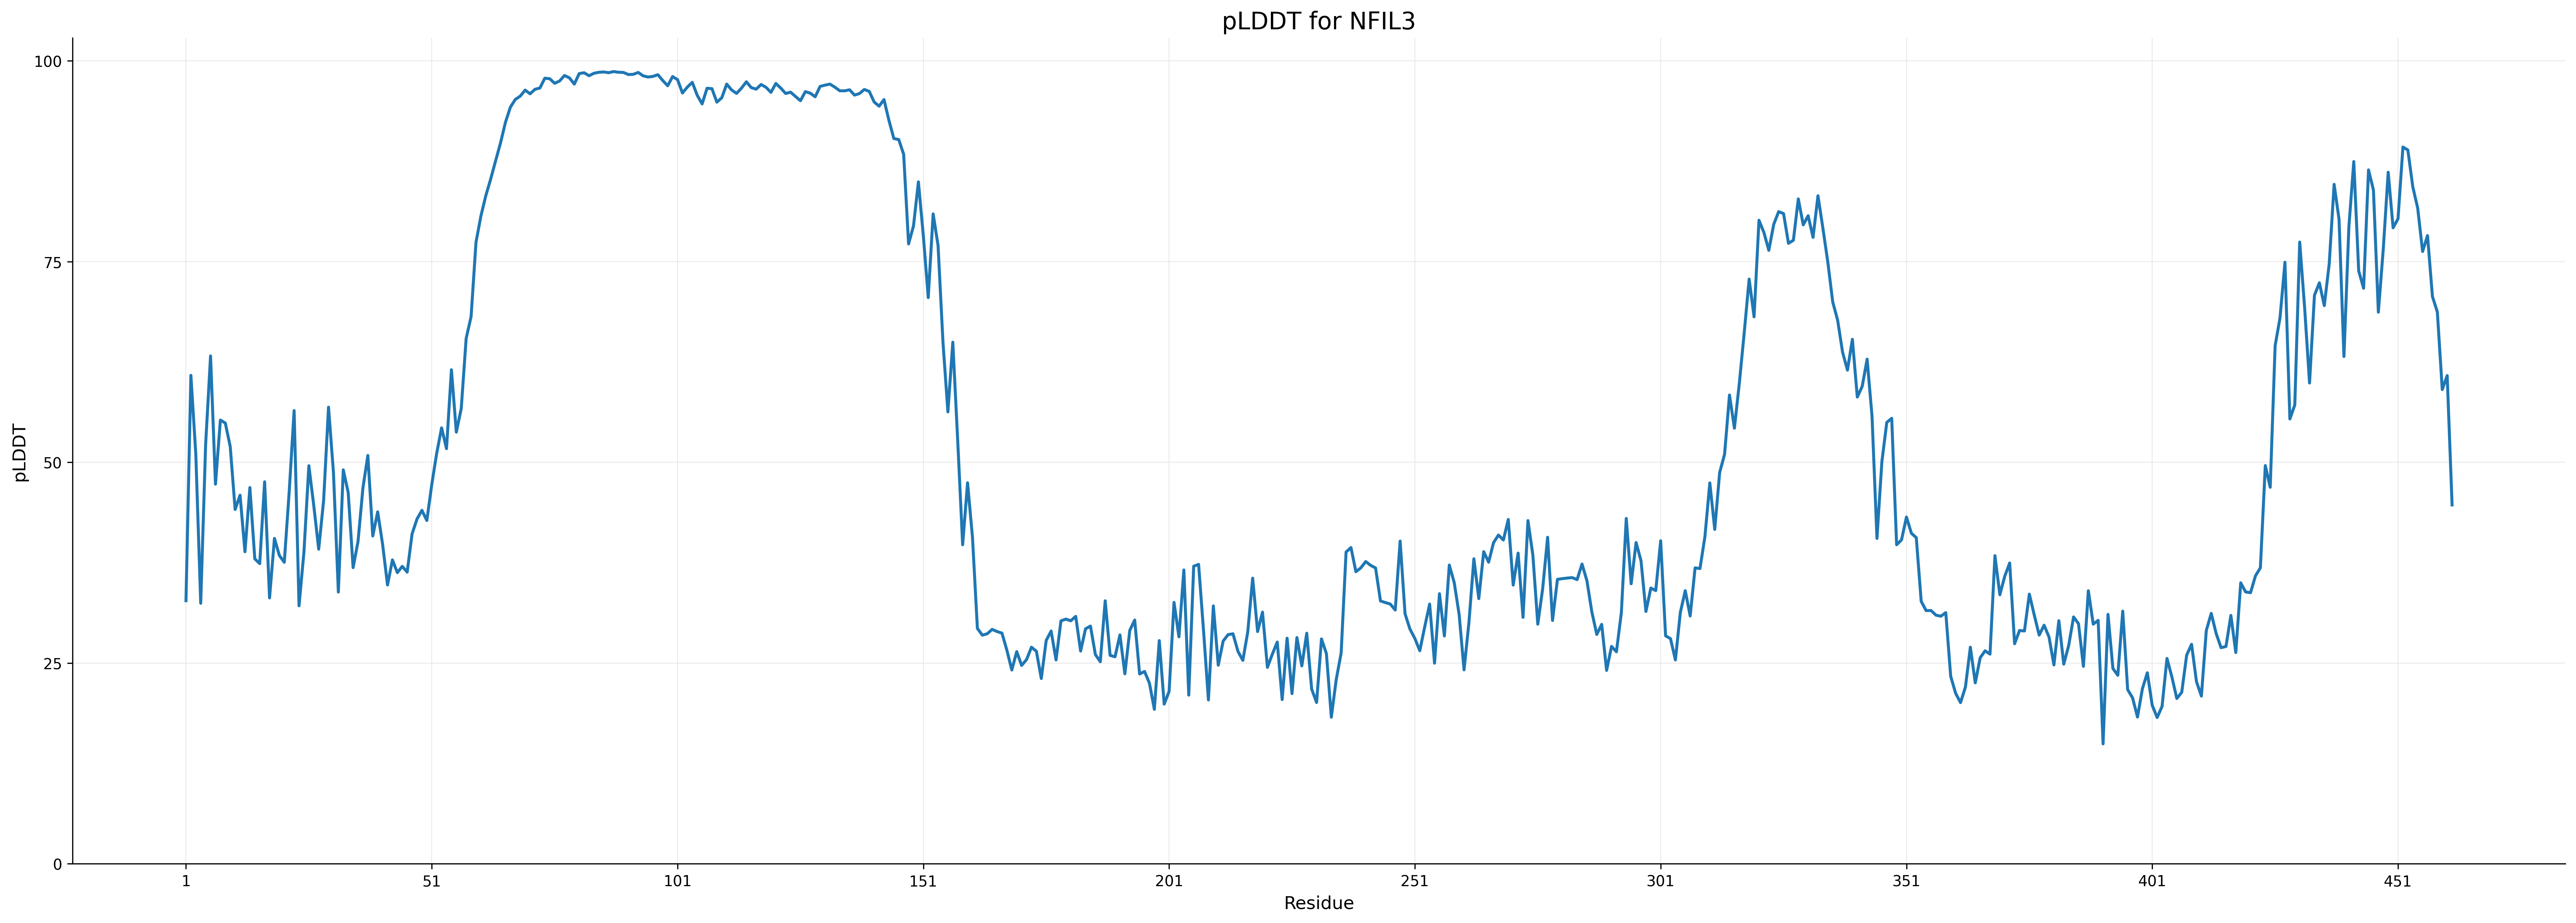

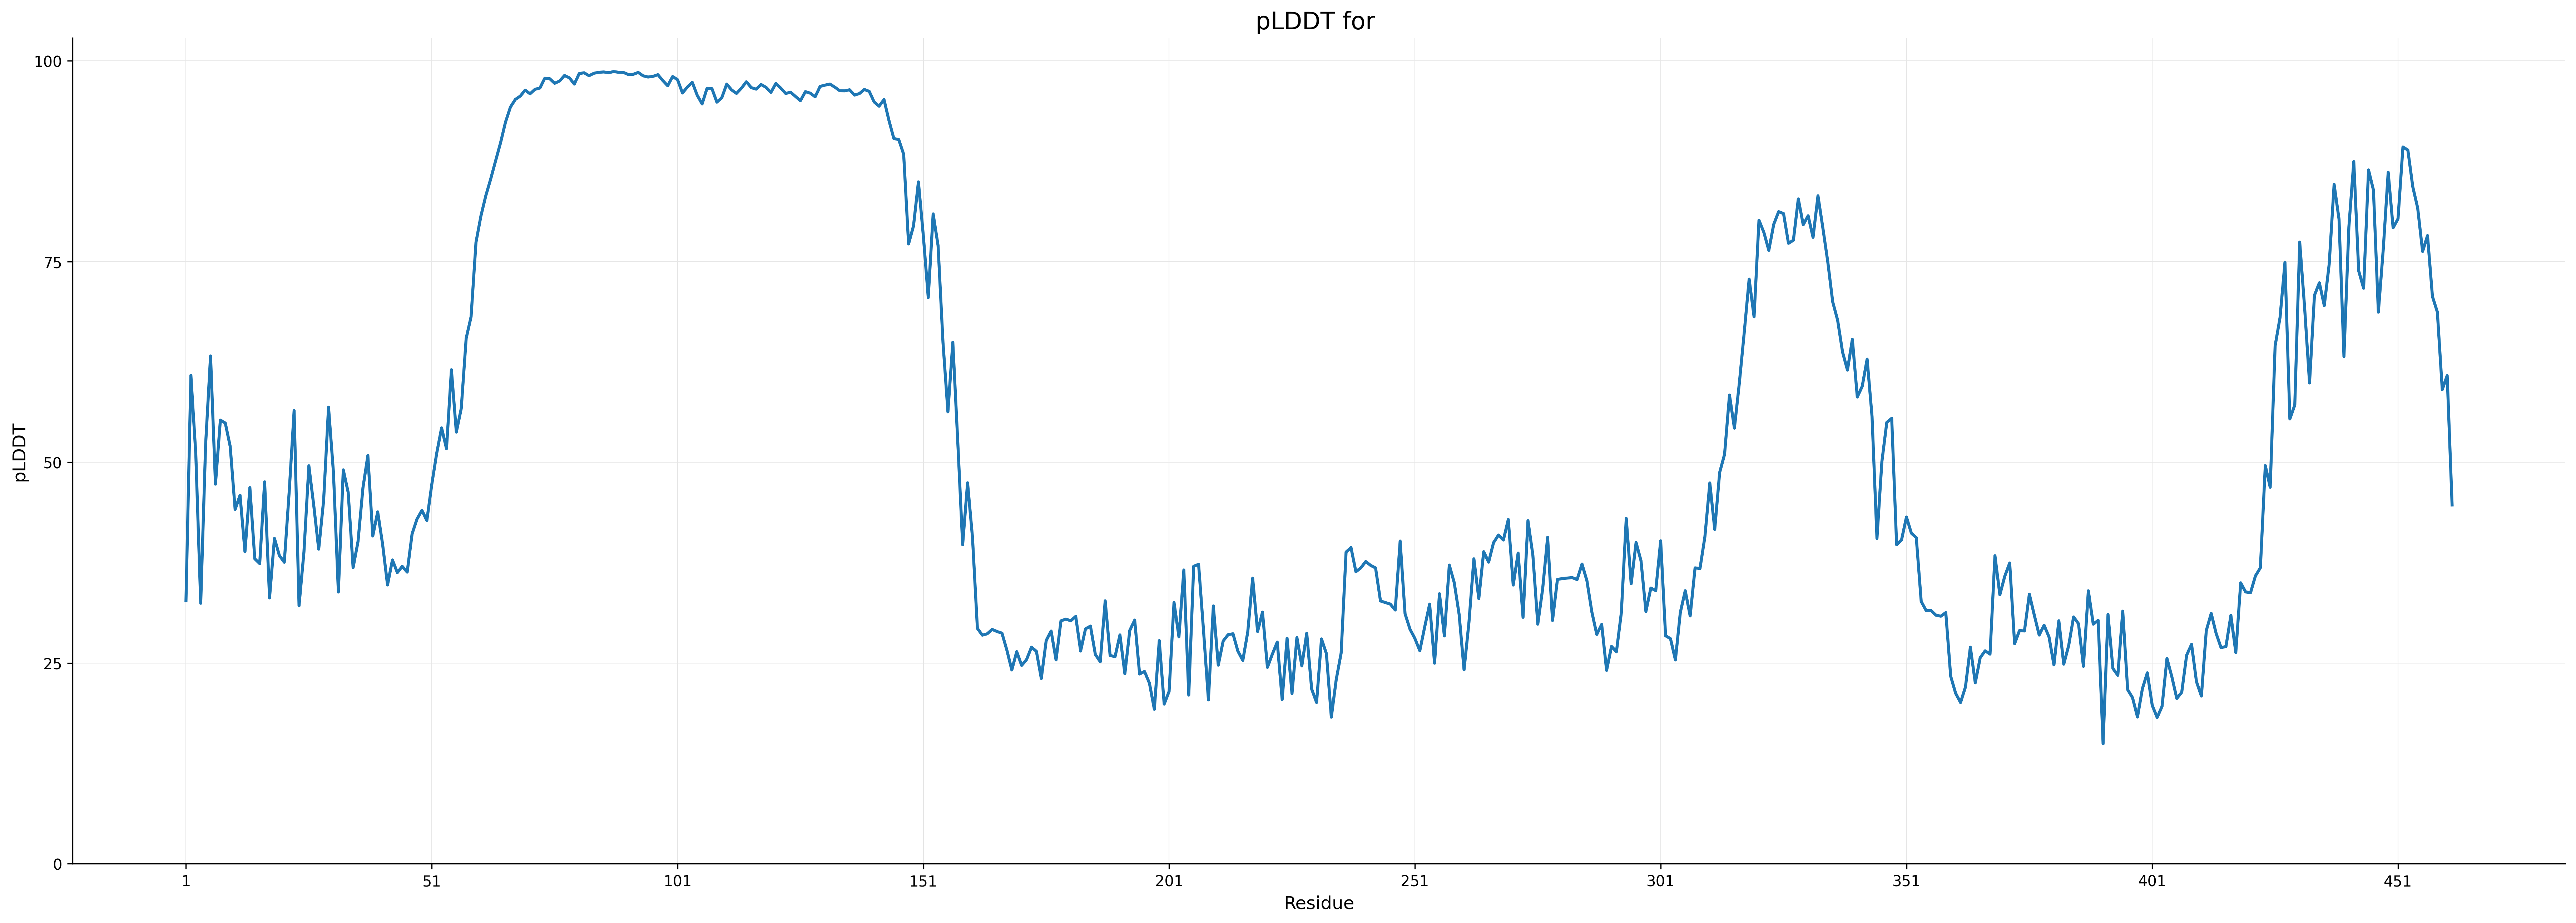

In [ ]:
#TO DO: Fix the bug to plot_plDDT function...
#plot_plddt(f"{base_path}/", name_protA, name_protB)

### PPI reliability with LIS and cLIS scores

In [ ]:
def df_to_plot(base_path, csv_file, protein, metric, save="png", nbr_res=1):
    """
    Function that plots the maximum value of the LIS output dataframe across the entire protein.
    
    Parameters:
        - base_path (str): Path for the input .csv file and for the output graph
        - csv_file (str): Name of the LIS output .csv file to be analyzed
        - protein (str): Name of the protein
        - metric (str):  Input matrix to be studied (Lis or cLis)
        - nbr_res (int): Number of residues present upstream of the protein of interest
        - save (str): File plot format (PDF or PNG)
    """

    # Select the maximum values
    df = pd.read_csv(f"{base_path}/Matrices/{csv_file}.csv")
    df = df.iloc[:, 1:]
    df_max = pd.DataFrame([df.max()])

    # Converting columns to match residue numbers
    if csv_file == "matrix_lis_BvsA" or csv_file == "matrix_clis_BvsA":
        df_max.columns = [(int(col) + nbr_res) for col in df_max.columns]
    elif csv_file == "matrix_lis_AvsB" or csv_file == "matrix_clis_AvsB":
        df_max.columns = [((int(col) - (nbr_res))+1) for col in df_max.columns]

    # Create save path
    save_path = f"{base_path}/Plots/"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Plot
    ax = df_max.T.plot(kind="bar", legend=False, width=1.0)
    plt.grid(color="0.9", linestyle="-", linewidth=0.5, zorder=0)
    plt.grid(True, axis='x', zorder=3)
    plt.grid(True, axis='y', zorder=3)
    for patch in ax.patches:
        patch.set_zorder(2)

    ax.figure.set_size_inches(6,4)
    plt.gca().xaxis.set_major_locator(MultipleLocator(25))
    plt.xticks(rotation=45)
    plt.xlabel(f"{protein} residues")
    plt.ylabel(f"MAX {metric}")
    plt.ylim(0,1)
    plt.title(f"Max {metric} values for {protein} residues")
    plt.savefig(f"{save_path}{csv_file}_{protein}_all.{save}", dpi=300)
    plt.show()
    
    print(f"Results saved in {base_path}/{csv_file}_{protein}_all.{save}")
        

In [ ]:
def df_to_plot_zoom(base_path, csv_file, protein, metric, begin, end, save="png", nbr_res=1):
    """
    Function that plots the maximum value of the LIS output dataframe across the entire protein.
    
    Parameters: 
        - base_path (str): Path for the input .csv file and for the output graph
        - csv_file (str): Name of the LIS output .csv file to be analyzed
        - protein (str): Name of the protein
        - metric (str):  Input matrix to be studied (Lis or cLis)
        - begin (int): Start of zoom (first residue)
        - end (int): End of zoom (last residue)
        - nbr_res (int): Number of residues present upstream of the protein of interest
        - save (str): File plot format (PDF or PNG)
    """

    # Select the maximum values
    df = pd.read_csv(f"{base_path}/Matrices/{csv_file}.csv")
    df = df.iloc[:, 1:]
    df_max = pd.DataFrame([df.max()])

    # Converting columns to match residue numbers
    if csv_file == "matrix_lis_BvsA" or csv_file == "matrix_clis_BvsA":
        df_max.columns = [(int(col) + nbr_res) for col in df_max.columns]
    elif csv_file == "matrix_lis_AvsB" or csv_file == "matrix_clis_AvsB":
        df_max.columns = [((int(col) - (nbr_res))+1) for col in df_max.columns]

    # Adjusts the dataframe to the desired region (zoom)
    df_max = df_max.iloc[:, begin-1:end]

    # Create save path
    save_path = f"{base_path}/Plots/"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Plot
    ax = df_max.T.plot(kind="bar", legend=False, width=1.0)
    plt.grid(color="0.9", linestyle="-", linewidth=0.5, zorder=0)
    plt.grid(True, axis='x', zorder=3)
    plt.grid(True, axis='y', zorder=3)
    for patch in ax.patches:
        patch.set_zorder(2)

    ax.figure.set_size_inches(6,4)
    plt.gca().xaxis.set_major_locator(MultipleLocator(2))
    plt.xticks(rotation=45)
    plt.xlabel(f"{protein} residues")
    plt.ylabel(f"MAX {metric}")
    plt.ylim(0,1)
    plt.title(f"Max {metric} values for {protein} {begin}-{end}")
    plt.savefig(f"{save_path}{csv_file}_{protein}_{begin}_{end}.{save}", dpi=300)
    plt.show()
    
    print(f"Results saved in {base_path}/{csv_file}_{protein}_{begin}_{end}.{save}")


In [ ]:
def df_to_bar_plot(base_path, csv_file, dataframe, protein, metric, index_x, index_y, save="png"):
    """
    Function that plots protein residues with their max and average Lis/cLis values.
    
    Parameters: 
        - base_path (str): Path for the input .csv file and for the output graph
        - csv_file (str): Name of the LIS output .csv file to be analyzed
        - dataframe (pd.DataFrame): Dataframe with Lis/cLis results
        - protein (str): Name of the protein
        - metric (str):  Input matrix to be studied (Lis or cLis)
        - index_x/y (int): X and Y size of the graph
        - save (str): File plot format (PDF or PNG)
    """
                
    # Unique positions for each line for the bar plot
    x_pos = range(len(dataframe))

    # Plot
    plt.figure(figsize=(index_x, index_y), dpi=300)
    plt.grid(color="0.9", linestyle="-", linewidth=0.5, zorder=1)

    plt.bar(x_pos, dataframe[f"Max_{metric}"], color="#1f77b4", label=f"{metric} max value ", zorder=2)
    plt.scatter(x_pos, dataframe[f"Mean_{metric}"], color="#d62728", label=f"{metric} mean value", zorder=3)
    
    plt.title(f"{metric} positive values for residues in {protein}", fontsize=16)
    plt.ylim(0, 1)
    plt.ylabel(f"{metric} values", fontsize=12)
    plt.xticks(x_pos, dataframe["Residue_Position"], rotation=45)
    plt.xlabel("Residue position", fontsize=12)
    plt.legend()
    plt.savefig(f"{base_path}/Plots/{csv_file}_{protein}_results.{save}", dpi=300) 
    plt.show()
    
    print(f"Results saved in {base_path}/Plots/{csv_file}_{protein}_results.{save}")
    

In [ ]:
def compute_LIA_per_residue(base_path, csv_file, nbr_res=1, threshold=0.6):
    """
    Calculate the effective LIA (number of partners) for each residue of proteins A or B.
    
    Parameters:
        - base_path (str): Path for the input .csv file
        - csv_file (str): Name of the LIS output .csv file to be analyzed
        - nbr_res (int): Number of residues present upstream of the protein of interest
        - threshold (float): effective threshold at which protein interaction is confirmed
    Returns:
        - df_lia: DataFrame with effective LIA for each residue for a given protein
    """
    
    # Reading matrix
    lis = pd.read_csv(f"{base_path}/Matrices/{csv_file}.csv", index_col=0)

    if csv_file == "matrix_lis_AvsB":
        masque_AB = lis >= threshold
        lia_A = masque_AB.sum(axis=0)
        nbr_res= nbr_res - 1
        df_lia = pd.DataFrame({"Position": (lia_A.index.astype(int) - nbr_res), "LIA_effectif": lia_A.values})
    
    elif csv_file == "matrix_lis_BvsA":
        masque_BA = lis >= threshold  
        lia_B = masque_BA.sum(axis=0)
        nbr_res= nbr_res - 2
        df_lia = pd.DataFrame({"Position": (lia_B.index.astype(int) - nbr_res), "LIA_effectif": lia_B.values})
        
    else:
        df_lia = None
        print("Input matrix: 'matrix_lis_AvsB' or 'matrix_lis_BvsA'. ")
    
    return df_lia
    

In [ ]:
def analyze_df(base_path, csv_file, name, zoom=False, save="png", index_x=16, index_y=8):
    """
    Create a matrix with the position of residues whose LIS values >0, as well as their maximum and average values.
    Shows and saves the corresponding graphs.
    
    Parameters:
        - base_path (str): Input path of the folder containing the .csv/.json files, then output path of the results matrix and graph
        - csv_file (str): Name of the LIS output .csv file to be analyzed
        - name (str): Name of the protein being studied
        - zoom (bool): Zoomed or unzoomed graphic
        - save (str): File plot format (PDF or PNG)
        - index_x/y (int): Output graph size in x/y
    Returns:
        - results: Dataframe with Lis/cLis values and position of residues
    """
    
    # Selection of .csv and .json files required
    df = pd.read_csv(f"{base_path}/Matrices/{csv_file}.csv")
    identifier = os.path.basename(base_path)

    with open(f"{base_path}/{identifier}_job_request.json", "r") as f:
        data = json.load(f)

    # Matrix selection
    if csv_file == "matrix_lis_BvsA" or csv_file == "matrix_clis_BvsA":
        # Positive columns without the first
        mask = (df > 0).any(axis=0)
        cols_pos = df.loc[:, mask]            
        cols_pos = cols_pos.iloc[:, 1:]

        # Find the maximum value and calculate the average
        mean_values = cols_pos[cols_pos > 0].mean()
        max_values = cols_pos[cols_pos > 0].max()

        # Update of the sequence and positions of each residue
        sequence = data[0]["sequences"][0]["proteinChain"]["sequence"]
        new_index = [int(i) + 1 for i in mean_values.index]

        if csv_file == "matrix_lis_BvsA":
            if zoom == False:
                # Plot the graph with max values of Lis overall protein
                df_to_plot(base_path, csv_file, name, "Lis", save)
                
            else:
                # Plot the graph with max values of Lis in user-defined region
                begin = input(print("First residue:\n"))
                begin = int(begin)
                end = input(print("Last residu:\n"))
                end = int(end)
                df_to_plot_zoom(base_path, csv_file, name, "Lis", begin, end, save)
            
            # Creating the dataframe
            results = pd.DataFrame({"Residue": [sequence[int(i)-1] for i in new_index], 
                                    "Position": new_index,       
                                    "Mean_Lis": mean_values.values, 
                                    "Max_Lis": max_values.values})  
            results.insert(2, "Residue_Position", results["Residue"] + results["Position"].astype(str))

            # Effective LIA calculation
            df_lia = compute_LIA_per_residue(base_path, csv_file)
            results = pd.merge(results, df_lia, on="Position", how="left")

            # Plot the residual graph with positive values of Lis
            df_to_bar_plot(base_path, csv_file, results, name, "Lis", index_x, index_y, save)
            
        elif csv_file == "matrix_clis_BvsA":   
            if zoom == False:
                # Plot the graph with max values of cLis overall protein
                df_to_plot(base_path, csv_file, name, "cLis", save)
                
            else:
                # Plot the graph with max values of cLis in user-defined region
                begin = input(print("First residue:\n"))
                begin = int(begin)
                end = input(print("Last residue:\n"))
                end = int(end)
                df_to_plot_zoom(base_path, csv_file, name, "cLis", begin, end, save)


            # Creating the dataframe
            results = pd.DataFrame({"Residue": [sequence[int(i)-1] for i in new_index], 
                                    "Position": new_index, 
                                    "Mean_cLis": mean_values.values, 
                                    "Max_cLis": max_values.values})
            results.insert(2, "Residue_Position", results["Residue"] + results["Position"].astype(str))

            # Plot the residual graph with positive values of cLis
            df_to_bar_plot(base_path, csv_file, results, name, "cLis", index_x, index_y, save)
        
    elif csv_file == "matrix_lis_AvsB" or csv_file == "matrix_clis_AvsB": 
        # Positive columns without the first
        mask = (df > 0).any(axis=0)
        cols_pos = df.loc[:, mask]
        cols_pos = cols_pos.iloc[:, 1:]

        # Find the maximum value and calculate the average
        mean_values = cols_pos[cols_pos > 0].mean()
        max_values = cols_pos[cols_pos > 0].max()
               
        # Update of the sequence and positions of each residue
        sequence1 = data[0]["sequences"][0]["proteinChain"]["sequence"]
        sequence2 = data[0]["sequences"][1]["proteinChain"]["sequence"]
        nbr_res = len(sequence1)
        new_index = [(int(i) - int(nbr_res) + 1) for i in mean_values.index]

        if csv_file == "matrix_lis_AvsB":
            if zoom == False:
                # Plot the graph with max values of Lis overall protein
                df_to_plot(base_path, csv_file, name, "Lis", save, nbr_res)
                
            else:
                # Plot the graph with max values of Lis in user-defined region
                begin = input(print("First residue:\n"))
                begin = int(begin)
                end = input(print("Last residue:\n"))
                end = int(end)
                df_to_plot_zoom(base_path, csv_file, name, "Lis", begin, end, save, nbr_res)

            # Creating the dataframe
            results = pd.DataFrame({"Residue": [sequence2[int(i)-1] for i in new_index], 
                                    "Position": new_index, 
                                    "Mean_Lis": mean_values.values, 
                                    "Max_Lis": max_values.values})
            results.insert(2, "Residue_Position", results["Residue"] + results["Position"].astype(str))

            # LIA calculation
            nbr_res = len(sequence1)
            df_lia = compute_LIA_per_residue(base_path, csv_file, nbr_res)
            results = pd.merge(results, df_lia, on="Position", how="left")

            # Plot the residual graph with positive values of Lis
            df_to_bar_plot(base_path, csv_file, results, name, "Lis", index_x, index_y, save)
            
        elif csv_file == "matrix_clis_AvsB":
            if zoom == False:
                # Plot the graph with max values of cLis overall protein
                df_to_plot(base_path, csv_file, name, "cLis", save, nbr_res)
                
            else:
                # Plot the graph with max values of cLis in user-defined region
                begin = input(print("Start of residual zoom n° \n"))
                begin = int(begin)
                end = input(print("End of residual zoom n° \n"))
                end = int(end)
                df_to_plot_zoom(base_path, csv_file, name, "cLis", begin, end, save, nbr_res)

            # Creating the dataframe
            results = pd.DataFrame({"Residue": [sequence2[int(i)-1] for i in new_index], 
                                    "Position": new_index, 
                                    "Mean_cLis": mean_values.values, 
                                    "Max_cLis": max_values.values})
            results.insert(2, "Residue_Position", results["Residue"] + results["Position"].astype(str))

            # Plot the residual graph with positive values of cLis
            df_to_bar_plot(base_path, csv_file, results, name, "cLis", index_x, index_y, save)
    
    else:
        print(f"The path {base_path}/Matrices/ does not contain usable .csv and/or .json files... ")
        return(None)

    return(results)
    

### Plot LIS and cLIS

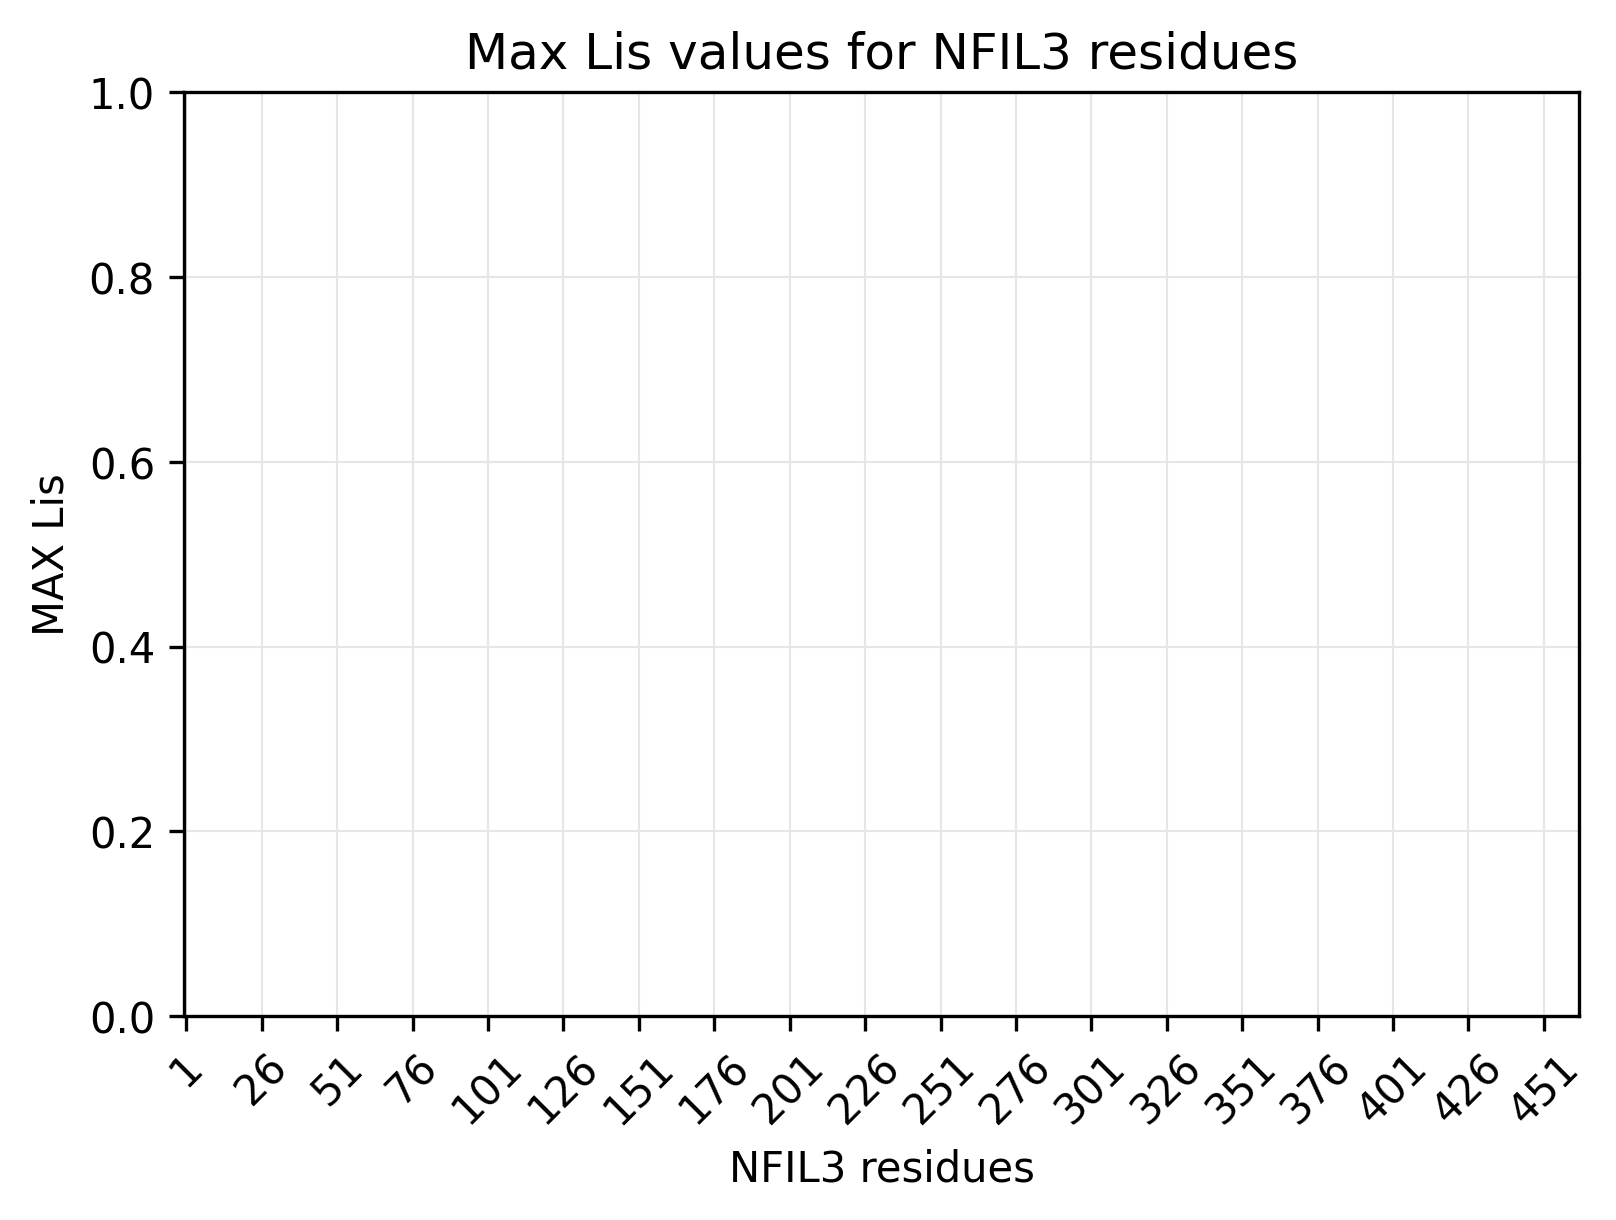

Results saved in C:/Users/e216138h/Downloads/fold_mnfil3_mpcgf6/matrix_lis_BvsA_NFIL3_all.png


In [ ]:
matrix_lis_BvsA = analyze_df(base_path, "matrix_lis_BvsA", name_protA)

In [ ]:
matrix_clis_BvsA = analyze_df(base_path, "matrix_clis_BvsA", name_protA)

In [ ]:
matrix_lis_AvsB = analyze_df(base_path, "matrix_lis_AvsB", name_protB, index_x=30, index_y=10)

In [ ]:
matrix_clis_AvsB = analyze_df(base_path, "matrix_clis_AvsB", name_protB)

### Compute the LIA score from LIS

In [ ]:
def compute_LIA_from_AB_files(base_path, csv_file_lis_AB, csv_file_lis_BA, threshold=0.6):
    """
    Function that calculates an effective LIA based on LIS AvsB and BvsA scores, to study inter-chain interactions in both directions.
    
    Parameters:
        - base-path (str): File input files
        - csv_file_lis_AB/BA (str): Names of .csv files used
        - threshold (float): threshold LIS to define effective LIA
    """
    
    # Reading of the two inter-chain matrix
    lis_AB = pd.read_csv(f"{base_path}/Matrices/{csv_file_lis_AB}.csv", index_col=0).values
    lis_BA = pd.read_csv(f"{base_path}/Matrices/{csv_file_lis_BA}.csv", index_col=0).values

    # Masks for pairs above the threshold
    masque_AB = lis_AB >= threshold
    df_masque_AB = pd.DataFrame(masque_AB)
    
    masque_BA = lis_BA >= threshold
    df_masque_BA = pd.DataFrame(masque_BA)    

    # Effective LIA = number of pairs in each direction
    lia_AB = int(np.sum(masque_AB))
    lia_BA = int(np.sum(masque_BA))
    
    # Total LIA = sum (or average)
    lia_effective_total = lia_AB + lia_BA  # np.mean([lia_AB, lia_BA])
    
    # Average LIS on selected pairs
    lis_moyen_AB = float(lis_AB[masque_AB].mean()) if lia_AB > 0 else np.nan
    lis_moyen_BA = float(lis_BA[masque_BA].mean()) if lia_BA > 0 else np.nan
    lis_moyen_total = (lis_moyen_AB + lis_moyen_BA) / 2

    return {
        "LIA_AB": lia_AB,
        "LIA_BA": lia_BA, 
        "LIA_total": lia_effective_total,
        "LIS_moyen_AB": lis_moyen_AB,
        "LIS_moyen_BA": lis_moyen_BA,
        "LIS_moyen_total": lis_moyen_total
    }
    

In [ ]:
score_lia = compute_LIA_from_AB_files(base_path, "matrix_lis_AvsB", "matrix_lis_BvsA")
print(score_lia)

### Merged/filtered the data for each proteins

In [ ]:
def merged_df(base_path, df1, df2, protein):
    """
    Merges two csv files and returns the dataframe.
    
    Parameters:
        - base_path (str): Current directory
        - csv_file1/2 (str): .csv files to merge
        - protein (str): Protein name to study
    """
    
    # Selecting which columns to keep
    new_df1 = df1[["Residue_Position", "Mean_Lis", "Max_Lis"]] # , "LIA_effectif"
    new_df2 = df2[["Residue_Position", "Mean_cLis", "Max_cLis"]]
    
    # Merge on the key
    merged_df = pd.merge(new_df1, new_df2, on="Residue_Position", how="left")
    merged_df = merged_df.fillna(0)

    return(merged_df)
        

In [ ]:
def filtering_df(base_path, df1, df2, protein, polaire="none", metric="none", threshold=-1):
    """
    Filters a dataframe with specific Lis/clis and/or polar residue parameters and returns a new dataframe.
    
    Parameters:
        - base_path (str): Current directory
        - csv_file1/2 (str): .csv files to merge
        - protein (str): Protein name to study
        - polaire (str): Polar residues to be selected
        - metric (str) Metrics to filter (Lis/clis)
        - threshold (float): Threshold value
    """

    # Merging dataframes
    merged = merged_df(base_path, df1, df2, protein)

    
    # Dataframe with only the requested polar residues
    if polaire == "neg":
        filtered_merged = merged[merged["Residue_Position"].astype(str).str.startswith(("E", "D", "N", "Q"), na=False)]

    elif polaire == "pos":
        filtered_merged = merged[merged["Residue_Position"].astype(str).str.startswith(("K", "R", "H", "N", "Q"), na=False)]

    elif polaire == "all":
        filtered_merged = merged[merged["Residue_Position"].astype(str).str.startswith(("E", "D", "K", "R", "H", "N", "Q"), na=False)]
        
    elif polaire == "none":
        filtered_merged = merged
        
    else:
        print("The polar residue filter must be set to ‘pos’, ‘neg’, ‘all’ or ‘none’. ")

    
    # Dataframe with only the requested clis/Lis values
    if metric == "Lis":
        filtered_merged = filtered_merged[(filtered_merged["Mean_Lis"] >= threshold) | (filtered_merged["Max_Lis"] >= threshold)]
    
    elif metric == "cLis":
        filtered_merged = filtered_merged[(filtered_merged["Mean_cLis"] >= threshold) | (filtered_merged["Max_cLis"] >= threshold)]
    
    elif metric == "all":
        filtered_merged = filtered_merged[(filtered_merged["Mean_Lis"] >= threshold)
                        | (filtered_merged["Max_Lis"] >= threshold)
                        | (filtered_merged["Mean_cLis"] >= threshold) 
                        | (filtered_merged["Max_cLis"] >= threshold)]
    
    elif metric == "none":
        filtered_merged = filtered_merged

    else:
        print("The filter on metrics values must be set to ‘Lis’, ‘cLis’, ‘all’ or ‘none’. ")

    save_path = f"{base_path}/CSV/"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    filtered_merged.to_csv(f"{save_path}results_{protein}.csv")
    
    return(filtered_merged)
    

In [ ]:
results_protA = filtering_df(base_path, matrix_lis_BvsA, matrix_clis_BvsA, name_protA)
results_protA

In [ ]:
results_protB = filtering_df(base_path, matrix_lis_AvsB, matrix_clis_AvsB, name_protB)
results_protB